# LAB 3. SINGULAR VALUE DECOMPOSITION (SVD)


In [1]:
import numpy as np
import pandas as pd
from scipy.sparse.linalg import svds
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Task 1: SVD Implementation

In [2]:
def make_SVD(A):
    A_AT =A@A.T
    eigenvalues, eigenvectors = np.linalg.eigh(A_AT)
    sorted_idx = np.argsort(eigenvalues)[::-1] #indexes of how it was sorted
    eigenvalues = eigenvalues[sorted_idx]
    U = eigenvectors[:, sorted_idx]
    singular_values = np.sqrt(np.maximum(eigenvalues, 0))
    sigma = singular_values[singular_values>0]
    U = U[:, singular_values>0]

    V = []
    for i in range(len(sigma)):
        u_i = U[:, i]
        v_i = (A.T @ u_i) / sigma[i]
        V.append(v_i)

    V = np.array(V).T

    return U, np.diag(sigma), V.T

In [3]:
def check_SVD(A, U, sigma, VT):
    print("\nA:")
    print(A)
    res_A=(U @ sigma) @ VT
    print("\nU @ sigma @ V_T:")
    print(res_A)

In [4]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12]
])

U, sigma, VT=make_SVD(A)
U, sigma, VT

(array([[-0.14087668, -0.82471435,  0.47537679],
        [-0.34394629, -0.42626394, -0.83661763],
        [-0.54701591, -0.02781353,  0.24710489],
        [-0.75008553,  0.37063688,  0.11413595]]),
 array([[2.54624074e+01, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.29066168e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 2.48922841e-07]]),
 array([[-5.04533146e-01, -5.74515704e-01, -6.44498262e-01],
        [ 7.60775682e-01,  5.71405195e-02, -6.46494643e-01],
        [ 3.56808727e-09,  1.78404363e-09,  0.00000000e+00]]))

In [5]:
check_SVD(A, U, sigma, VT)


A:
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]

U @ sigma @ V_T:
[[ 1.  2.  3.]
 [ 4.  5.  6.]
 [ 7.  8.  9.]
 [10. 11. 12.]]


## Task 2


### PART 1: Recommendation Algorithm, Data Visualization


In [6]:
file_path = 'ml-latest-small/ratings.csv'
df = pd.read_csv(file_path)
ratings_matrix = df.pivot(index='userId', columns='movieId',
values='rating')

In [7]:
ratings_matrix.shape

(610, 9724)

In [8]:
ratings_matrix = ratings_matrix.dropna(thresh=200, axis=0)
ratings_matrix = ratings_matrix.dropna(thresh=100, axis=1)


In [9]:
ratings_matrix.shape

(134, 6)

In [10]:
ratings_matrix.describe

<bound method NDFrame.describe of movieId  260   296   356   1196  1210  2571
userId                                     
1         5.0   3.0   4.0   5.0   5.0   5.0
4         5.0   1.0   NaN   5.0   NaN   1.0
6         NaN   2.0   5.0   NaN   NaN   NaN
18        4.0   4.0   4.5   4.0   4.5   4.5
19        4.0   NaN   2.0   4.0   3.0   4.0
...       ...   ...   ...   ...   ...   ...
603       4.0   5.0   3.0   3.0   3.0   5.0
605       5.0   2.0   3.0   NaN   5.0   NaN
606       4.5   5.0   4.0   4.5   4.5   5.0
608       3.5   5.0   3.0   4.0   4.0   5.0
610       5.0   5.0   3.0   5.0   5.0   5.0

[134 rows x 6 columns]>

In [11]:
ratings_matrix_filled = ratings_matrix.fillna(2.5)

R = ratings_matrix_filled.values
user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)


In [12]:
U, sigma, Vt = svds(R_demeaned, k=3)

Sigma = np.diag(sigma)

print("U shape (Users):", U.shape)
print("Vt shape (Movies T):", Vt.shape)


U shape (Users): (134, 3)
Vt shape (Movies T): (3, 6)


In [13]:
U

array([[-0.11701519, -0.0486775 ,  0.10423191],
       [ 0.11847179, -0.08575014,  0.25393107],
       [ 0.04659884, -0.2114704 , -0.06167357],
       [-0.03369839, -0.03431137, -0.01493453],
       [-0.11315672,  0.06023676,  0.09295234],
       [ 0.        ,  0.        ,  0.        ],
       [-0.00176799, -0.06557723,  0.04769789],
       [ 0.0223581 ,  0.03028765, -0.01808238],
       [ 0.14094734,  0.18267287, -0.0629276 ],
       [-0.02632272, -0.00939526, -0.06325497],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.0808657 ,  0.0546264 , -0.07019834],
       [ 0.05670146,  0.0201186 ,  0.16508456],
       [-0.12109341, -0.04722163,  0.04750486],
       [-0.02915682, -0.03123462, -0.02748431],
       [ 0.09201204,  0.09678061,  0.06990315],
       [ 0.01555938,  0.02934068, -0.06364908],
       [-0.01879314, -0.00076514, -0.16784247],
       [-0.13257457, -0.07801818,  0.16788099],
       [-0.00475961, -0.0016749 , -0.01720317],
       [-0.05804253, -0.12877441,  0.021

In [14]:
def plot_3d2(U, n_users=20):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    xs = U[:n_users, 0]
    ys = U[:n_users, 1]
    zs = U[:n_users, 2]

    ax.scatter(xs, ys, zs, c=range(n_users), cmap='viridis', s=40, alpha=0.8)

    ax.grid(color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.set_xlabel('Latent Feature 1')
    ax.set_ylabel('Latent Feature 2')
    ax.set_zlabel('Latent Feature 3')
    ax.set_title(f'Users (Top {n_users}) in Latent Space')

    plt.show()

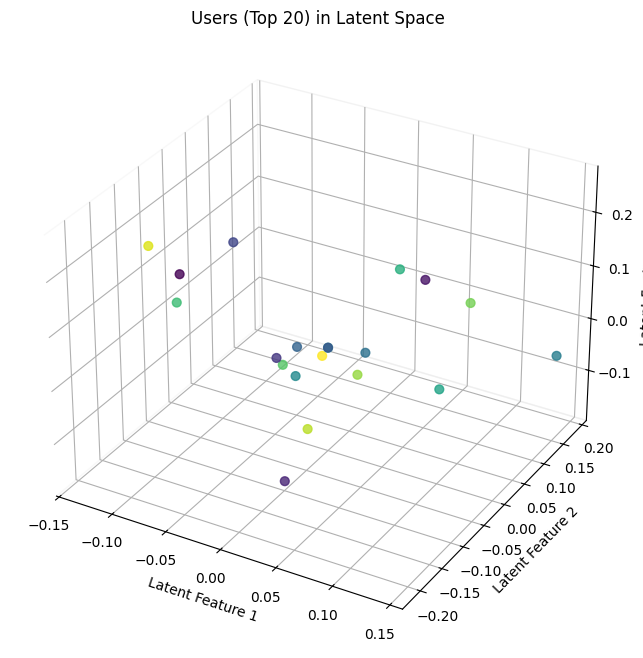

In [15]:
plt.style.use('default')
plot_3d2(U, n_users=20)

In [16]:
Vt.T

array([[ 0.09296504,  0.03512916,  0.45685515],
       [ 0.43669991,  0.63524784, -0.48020396],
       [ 0.2693743 , -0.76001901, -0.42360706],
       [ 0.12853428,  0.04926365,  0.41995691],
       [-0.08870624, -0.06453129,  0.33327777],
       [-0.83886728,  0.10490964, -0.30627881]])

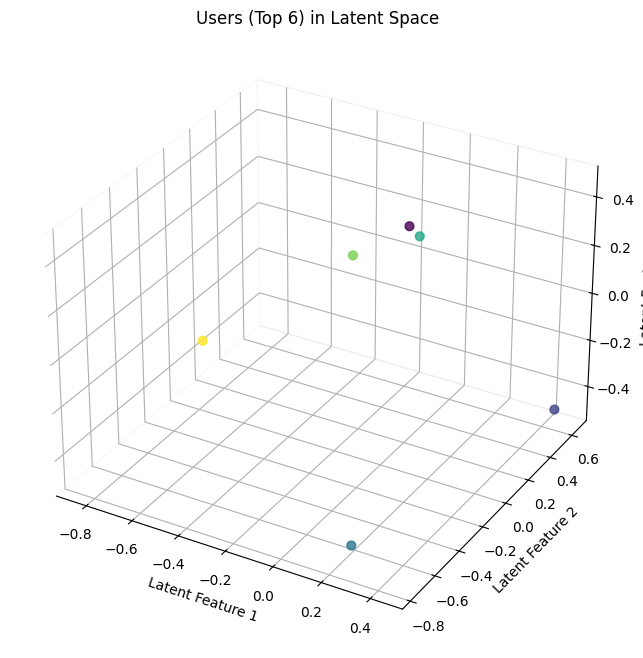

In [17]:
plot_3d2(Vt.T, n_users=6)

## PART 2: Recommendation Algorithm, Creating a Selection of Recommended Movies for Users

In [18]:
file_path = 'ml-latest-small/ratings.csv'
df = pd.read_csv(file_path)
ratings_matrix = df.pivot(index='userId', columns='movieId',
values='rating')

ratings_matrix = ratings_matrix.dropna(thresh=30, axis=0)
ratings_matrix = ratings_matrix.dropna(thresh=30, axis=1)

ratings_matrix_filled = ratings_matrix.fillna(2.5)

R = ratings_matrix_filled.values
user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

original_ratings_mask = ratings_matrix.notna()


In [19]:
def get_recommendations(user_id, predictions_df, movies_metadata, top_n=10):
    #if user_id not in predictions_df.index:
     #   return f"Користувач {user_id} був відфільтрований (мало оцінок)."

    user_predictions = predictions_df.loc[user_id]
    top_movies = user_predictions.sort_values(ascending=False).head(top_n)
    recommendations = pd.DataFrame(top_movies)
    recommendations.columns = ['Predicted Rating']
    recommendations.index.name = 'movieId'
    final_rec = recommendations.merge(movies_metadata, on='movieId', how='left')
    return final_rec[['title', 'genres', 'Predicted Rating']]



In [20]:
def check_user_history(user_id, ratings_matrix, movies_df):
    user_ratings = ratings_matrix.loc[user_id]
    user_history = user_ratings.dropna()
    user_history = user_history.sort_values(ascending=False).head(10)
    history_df = pd.DataFrame(user_history)
    history_df.index.name = 'movieId'
    history_df.columns = ['Rating']
    final_history = history_df.merge(movies_df, on='movieId', how='left')
    return final_history[['title', 'genres', 'Rating']]

### For k=3

In [21]:
k = 3
U, sigma, Vt = svds(R_demeaned, k)

Sigma = np.diag(sigma)
all_user_predicted_ratings = np.dot(np.dot(U, Sigma), Vt) + user_ratings_mean.reshape(-1, 1)

preds_df = pd.DataFrame(all_user_predicted_ratings,
                        columns=ratings_matrix_filled.columns,
                        index=ratings_matrix_filled.index)
preds_df

movieId,1,2,3,5,6,7,10,11,16,17,...,115617,116797,119145,122882,122886,122904,134130,134853,139385,152081
userId,,,,,,,,,,,,,,,,,,,,,
1,3.751467,2.850516,2.781028,2.629794,3.305636,2.694064,3.031969,3.027301,3.055600,3.010727,...,2.505191,2.435392,2.472326,2.475231,2.505257,2.396059,2.538664,2.511986,2.531858,2.468232
3,2.463197,2.484797,2.480001,2.485259,2.470484,2.483091,2.479295,2.473070,2.478098,2.472994,...,2.496070,2.500049,2.497244,2.498957,2.497536,2.502882,2.496671,2.496691,2.494863,2.496615
4,2.797973,2.474865,2.594042,2.512979,2.788636,2.539917,2.564718,2.640479,2.742725,2.742871,...,2.437648,2.393193,2.426057,2.421249,2.419134,2.343080,2.452738,2.438167,2.477850,2.424185
5,2.988966,2.723062,2.608511,2.574936,2.708824,2.598178,2.761060,2.752177,2.552674,2.610717,...,2.461291,2.431828,2.445538,2.427376,2.463858,2.439579,2.446005,2.454068,2.437062,2.455795
6,3.887858,3.432294,3.059707,3.013915,3.059059,3.071266,3.469088,3.499921,2.561951,2.909472,...,2.539726,2.442535,2.493109,2.394421,2.535558,2.486332,2.434004,2.495407,2.421118,2.547828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,3.345827,2.562138,2.616118,2.490039,3.286474,2.520747,2.737093,2.615831,3.327124,2.960949,...,2.759584,2.772888,2.755758,2.848474,2.784580,2.727270,2.887290,2.807489,2.857371,2.705361
607,3.585085,2.925017,2.741534,2.647054,3.054700,2.699397,3.035957,3.017103,2.761487,2.819868,...,2.458327,2.397126,2.426385,2.404277,2.463045,2.396068,2.449987,2.451479,2.433979,2.438284
608,3.444492,2.868842,2.595633,2.571474,3.153680,2.574802,2.942580,2.617248,3.173714,2.739826,...,2.989390,3.075436,2.995538,3.112504,3.063122,3.126659,3.113153,3.045336,3.013863,2.941660


In [22]:
original_values = ratings_matrix_filled[original_ratings_mask].values.flatten()
predicted_values = preds_df[original_ratings_mask].values.flatten()

mask = ~np.isnan(original_values)
rmse = np.sqrt(np.mean((original_values[mask] - predicted_values[mask])**2))

print(f"RMSE for k={k}: {rmse:.4f}")

RMSE for k=3: 1.1393


In [23]:
predictions_only_df = preds_df.copy()
predictions_only_df[ratings_matrix.notna()] = np.nan

In [24]:
ratings_matrix

movieId,1,2,3,5,6,7,10,11,16,17,...,115617,116797,119145,122882,122886,122904,134130,134853,139385,152081
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,5.0,4.0,4.0,3.0,4.0,4.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,NaN,NaN,NaN,NaN,2.5,NaN,2.5,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
preds_df

movieId,1,2,3,5,6,7,10,11,16,17,...,115617,116797,119145,122882,122886,122904,134130,134853,139385,152081
userId,,,,,,,,,,,,,,,,,,,,,
1,3.751467,2.850516,2.781028,2.629794,3.305636,2.694064,3.031969,3.027301,3.055600,3.010727,...,2.505191,2.435392,2.472326,2.475231,2.505257,2.396059,2.538664,2.511986,2.531858,2.468232
3,2.463197,2.484797,2.480001,2.485259,2.470484,2.483091,2.479295,2.473070,2.478098,2.472994,...,2.496070,2.500049,2.497244,2.498957,2.497536,2.502882,2.496671,2.496691,2.494863,2.496615
4,2.797973,2.474865,2.594042,2.512979,2.788636,2.539917,2.564718,2.640479,2.742725,2.742871,...,2.437648,2.393193,2.426057,2.421249,2.419134,2.343080,2.452738,2.438167,2.477850,2.424185
5,2.988966,2.723062,2.608511,2.574936,2.708824,2.598178,2.761060,2.752177,2.552674,2.610717,...,2.461291,2.431828,2.445538,2.427376,2.463858,2.439579,2.446005,2.454068,2.437062,2.455795
6,3.887858,3.432294,3.059707,3.013915,3.059059,3.071266,3.469088,3.499921,2.561951,2.909472,...,2.539726,2.442535,2.493109,2.394421,2.535558,2.486332,2.434004,2.495407,2.421118,2.547828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,3.345827,2.562138,2.616118,2.490039,3.286474,2.520747,2.737093,2.615831,3.327124,2.960949,...,2.759584,2.772888,2.755758,2.848474,2.784580,2.727270,2.887290,2.807489,2.857371,2.705361
607,3.585085,2.925017,2.741534,2.647054,3.054700,2.699397,3.035957,3.017103,2.761487,2.819868,...,2.458327,2.397126,2.426385,2.404277,2.463045,2.396068,2.449987,2.451479,2.433979,2.438284
608,3.444492,2.868842,2.595633,2.571474,3.153680,2.574802,2.942580,2.617248,3.173714,2.739826,...,2.989390,3.075436,2.995538,3.112504,3.063122,3.126659,3.113153,3.045336,3.013863,2.941660


In [26]:
predictions_only_df

movieId,1,2,3,5,6,7,10,11,16,17,...,115617,116797,119145,122882,122886,122904,134130,134853,139385,152081
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,2.850516,NaN,2.629794,NaN,2.694064,3.031969,3.027301,3.055600,3.010727,...,2.505191,2.435392,2.472326,2.475231,2.505257,2.396059,2.538664,2.511986,2.531858,2.468232
3,2.463197,2.484797,2.480001,2.485259,2.470484,2.483091,2.479295,2.473070,2.478098,2.472994,...,2.496070,2.500049,2.497244,2.498957,2.497536,2.502882,2.496671,2.496691,2.494863,2.496615
4,2.797973,2.474865,2.594042,2.512979,2.788636,2.539917,2.564718,2.640479,2.742725,2.742871,...,2.437648,2.393193,2.426057,2.421249,2.419134,2.343080,2.452738,2.438167,2.477850,2.424185
5,NaN,2.723062,2.608511,2.574936,2.708824,2.598178,2.761060,2.752177,2.552674,2.610717,...,2.461291,2.431828,2.445538,2.427376,2.463858,2.439579,2.446005,2.454068,2.437062,2.455795
6,3.887858,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.539726,2.442535,2.493109,2.394421,2.535558,2.486332,2.434004,2.495407,2.421118,2.547828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,NaN,2.562138,2.616118,2.490039,3.286474,NaN,2.737093,NaN,3.327124,NaN,...,2.759584,2.772888,2.755758,2.848474,2.784580,2.727270,2.887290,2.807489,2.857371,2.705361
607,NaN,2.925017,2.741534,2.647054,3.054700,2.699397,3.035957,NaN,2.761487,2.819868,...,2.458327,2.397126,2.426385,2.404277,2.463045,2.396068,2.449987,2.451479,2.433979,2.438284
608,NaN,NaN,NaN,2.571474,3.153680,2.574802,NaN,2.617248,NaN,2.739826,...,2.989390,3.075436,2.995538,3.112504,3.063122,3.126659,3.113153,3.045336,3.013863,2.941660


In [27]:
movies_df = pd.read_csv('ml-latest-small/movies.csv')

target_user = predictions_only_df.index[0]
print(f"Top-10 recommendations for user {target_user}:")

get_recommendations(target_user, predictions_only_df, movies_df, top_n=10)

Top-10 recommendations for user 1:


,title,genres,Predicted Rating
0,"Shawshank Redemption, The (1994)",Crime|Drama,4.394433
1,"Godfather, The (1972)",Crime|Drama,4.171305
2,Terminator 2: Judgment Day (1991),Action|Sci-Fi,4.128124
3,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,3.777468
4,Blade Runner (1982),Action|Sci-Fi|Thriller,3.768077
5,"Godfather: Part II, The (1974)",Crime|Drama,3.747852
6,Apollo 13 (1995),Adventure|Drama|IMAX,3.700129
7,Aliens (1986),Action|Adventure|Horror|Sci-Fi,3.683278
8,Casablanca (1942),Drama|Romance,3.667234
9,"Sixth Sense, The (1999)",Drama|Horror|Mystery,3.643399


In [28]:
target_user = 1
print(f"Movies that the user {target_user} has rated highly previously:")
check_user_history(target_user, ratings_matrix, movies_df)

Movies that the user 1 has rated highly previously:


,title,genres,Rating
0,Desperado (1995),Action|Romance|Western,5.0
1,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,5.0
2,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,5.0
3,Billy Madison (1995),Comedy,5.0
4,Rob Roy (1995),Action|Drama|Romance|War,5.0
5,Schindler's List (1993),Drama|War,5.0
6,"Fugitive, The (1993)",Thriller,5.0
7,"Jungle Book, The (1994)",Adventure|Children|Romance,5.0
8,Tommy Boy (1995),Comedy,5.0
9,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,5.0


### For k=10

In [29]:
k = 10
U, sigma, Vt = svds(R_demeaned, k)

Sigma = np.diag(sigma)
all_user_predicted_ratings = np.dot(np.dot(U, Sigma), Vt) + user_ratings_mean.reshape(-1, 1)

preds_df = pd.DataFrame(all_user_predicted_ratings,
                        columns=ratings_matrix_filled.columns,
                        index=ratings_matrix_filled.index)
preds_df

movieId,1,2,3,5,6,7,10,11,16,17,...,115617,116797,119145,122882,122886,122904,134130,134853,139385,152081
userId,,,,,,,,,,,,,,,,,,,,,
1,4.015621,2.841072,2.887029,2.671721,3.073391,2.493099,3.081936,2.556586,3.045347,2.195388,...,2.664955,2.096634,2.746164,2.649861,2.772042,2.547383,2.588086,2.531462,2.644911,2.519240
3,2.477621,2.523428,2.482086,2.486371,2.515022,2.475027,2.550204,2.403871,2.474350,2.373391,...,2.532565,2.455196,2.543491,2.536303,2.557242,2.539559,2.479757,2.523138,2.495346,2.535451
4,3.592315,2.614585,2.597381,2.515177,2.431471,2.474561,2.434764,2.579606,2.571572,2.783986,...,2.613850,2.389406,2.521584,2.465742,2.445463,2.461679,2.423230,2.513394,2.412951,2.460284
5,3.144730,2.809540,2.660980,2.649637,2.716094,2.676201,2.713276,2.784206,2.659516,2.743009,...,2.513824,2.493787,2.459512,2.431526,2.426628,2.443371,2.436517,2.489834,2.446097,2.469805
6,3.920537,3.698042,3.202904,3.164633,3.242622,3.290984,3.550612,3.627207,2.901483,3.158014,...,2.572729,2.474569,2.554030,2.489650,2.501300,2.458166,2.460352,2.543910,2.483201,2.561963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,3.102032,2.531768,2.553992,2.462817,2.783779,2.793998,2.113656,2.653081,2.942748,3.729202,...,2.531959,3.099610,2.326228,2.455377,2.396702,2.374607,2.688616,2.677037,2.601719,2.580667
607,3.104985,2.751551,2.689476,2.544116,3.090518,2.581972,3.006131,3.133712,2.685258,2.647078,...,2.448022,2.498942,2.498343,2.531643,2.595324,2.500900,2.728755,2.457799,2.624996,2.451788
608,2.506224,2.165187,2.556189,2.615198,4.063005,2.518437,3.706907,2.659018,3.905423,2.626277,...,1.955540,2.193797,2.198197,2.274777,2.308885,2.166209,2.262937,2.328453,2.491837,2.311325


4. АНАЛІЗ ПОХИБКИ (Task 4) ---

In [30]:
original_values = ratings_matrix_filled[original_ratings_mask].values.flatten()
predicted_values = preds_df[original_ratings_mask].values.flatten()

mask = ~np.isnan(original_values)
rmse = np.sqrt(np.mean((original_values[mask] - predicted_values[mask])**2))

print(f"RMSE for k={k}: {rmse:.4f}")

RMSE for k=10: 1.0269


### --- ПУНКТ 5: Створення таблиці тільки з прогнозами ---


In [31]:
predictions_only_df = preds_df.copy()
predictions_only_df[ratings_matrix.notna()] = np.nan

In [32]:
ratings_matrix

movieId,1,2,3,5,6,7,10,11,16,17,...,115617,116797,119145,122882,122886,122904,134130,134853,139385,152081
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,5.0,4.0,4.0,3.0,4.0,4.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,NaN,NaN,NaN,NaN,2.5,NaN,2.5,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
preds_df

movieId,1,2,3,5,6,7,10,11,16,17,...,115617,116797,119145,122882,122886,122904,134130,134853,139385,152081
userId,,,,,,,,,,,,,,,,,,,,,
1,4.015621,2.841072,2.887029,2.671721,3.073391,2.493099,3.081936,2.556586,3.045347,2.195388,...,2.664955,2.096634,2.746164,2.649861,2.772042,2.547383,2.588086,2.531462,2.644911,2.519240
3,2.477621,2.523428,2.482086,2.486371,2.515022,2.475027,2.550204,2.403871,2.474350,2.373391,...,2.532565,2.455196,2.543491,2.536303,2.557242,2.539559,2.479757,2.523138,2.495346,2.535451
4,3.592315,2.614585,2.597381,2.515177,2.431471,2.474561,2.434764,2.579606,2.571572,2.783986,...,2.613850,2.389406,2.521584,2.465742,2.445463,2.461679,2.423230,2.513394,2.412951,2.460284
5,3.144730,2.809540,2.660980,2.649637,2.716094,2.676201,2.713276,2.784206,2.659516,2.743009,...,2.513824,2.493787,2.459512,2.431526,2.426628,2.443371,2.436517,2.489834,2.446097,2.469805
6,3.920537,3.698042,3.202904,3.164633,3.242622,3.290984,3.550612,3.627207,2.901483,3.158014,...,2.572729,2.474569,2.554030,2.489650,2.501300,2.458166,2.460352,2.543910,2.483201,2.561963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,3.102032,2.531768,2.553992,2.462817,2.783779,2.793998,2.113656,2.653081,2.942748,3.729202,...,2.531959,3.099610,2.326228,2.455377,2.396702,2.374607,2.688616,2.677037,2.601719,2.580667
607,3.104985,2.751551,2.689476,2.544116,3.090518,2.581972,3.006131,3.133712,2.685258,2.647078,...,2.448022,2.498942,2.498343,2.531643,2.595324,2.500900,2.728755,2.457799,2.624996,2.451788
608,2.506224,2.165187,2.556189,2.615198,4.063005,2.518437,3.706907,2.659018,3.905423,2.626277,...,1.955540,2.193797,2.198197,2.274777,2.308885,2.166209,2.262937,2.328453,2.491837,2.311325


In [34]:
predictions_only_df

movieId,1,2,3,5,6,7,10,11,16,17,...,115617,116797,119145,122882,122886,122904,134130,134853,139385,152081
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,2.841072,NaN,2.671721,NaN,2.493099,3.081936,2.556586,3.045347,2.195388,...,2.664955,2.096634,2.746164,2.649861,2.772042,2.547383,2.588086,2.531462,2.644911,2.519240
3,2.477621,2.523428,2.482086,2.486371,2.515022,2.475027,2.550204,2.403871,2.474350,2.373391,...,2.532565,2.455196,2.543491,2.536303,2.557242,2.539559,2.479757,2.523138,2.495346,2.535451
4,3.592315,2.614585,2.597381,2.515177,2.431471,2.474561,2.434764,2.579606,2.571572,2.783986,...,2.613850,2.389406,2.521584,2.465742,2.445463,2.461679,2.423230,2.513394,2.412951,2.460284
5,NaN,2.809540,2.660980,2.649637,2.716094,2.676201,2.713276,2.784206,2.659516,2.743009,...,2.513824,2.493787,2.459512,2.431526,2.426628,2.443371,2.436517,2.489834,2.446097,2.469805
6,3.920537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.572729,2.474569,2.554030,2.489650,2.501300,2.458166,2.460352,2.543910,2.483201,2.561963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,NaN,2.531768,2.553992,2.462817,2.783779,NaN,2.113656,NaN,2.942748,NaN,...,2.531959,3.099610,2.326228,2.455377,2.396702,2.374607,2.688616,2.677037,2.601719,2.580667
607,NaN,2.751551,2.689476,2.544116,3.090518,2.581972,3.006131,NaN,2.685258,2.647078,...,2.448022,2.498942,2.498343,2.531643,2.595324,2.500900,2.728755,2.457799,2.624996,2.451788
608,NaN,NaN,NaN,2.615198,4.063005,2.518437,NaN,2.659018,NaN,2.626277,...,1.955540,2.193797,2.198197,2.274777,2.308885,2.166209,2.262937,2.328453,2.491837,2.311325


In [35]:
movies_df = pd.read_csv('ml-latest-small/movies.csv')

target_user = predictions_only_df.index[0]
print(f"Top-10 recommendations for user {target_user}:")

get_recommendations(target_user, predictions_only_df, movies_df, top_n=10)

Top-10 recommendations for user 1:


,title,genres,Predicted Rating
0,Terminator 2: Judgment Day (1991),Action|Sci-Fi,4.612747
1,Aliens (1986),Action|Adventure|Horror|Sci-Fi,4.147821
2,Austin Powers: The Spy Who Shagged Me (1999),Action|Adventure|Comedy,4.087244
3,Die Hard (1988),Action|Crime|Thriller,4.084033
4,Ferris Bueller's Day Off (1986),Comedy,3.983328
5,"Godfather, The (1972)",Crime|Drama,3.970432
6,"Sixth Sense, The (1999)",Drama|Horror|Mystery,3.943585
7,"Breakfast Club, The (1985)",Comedy|Drama,3.908356
8,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,3.868295
9,Stand by Me (1986),Adventure|Drama,3.737301


In [36]:
target_user = 1
print(f"Movies that the user {target_user} has rated highly previously:")
check_user_history(target_user, ratings_matrix, movies_df)

Movies that the user 1 has rated highly previously:


,title,genres,Rating
0,Desperado (1995),Action|Romance|Western,5.0
1,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,5.0
2,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,5.0
3,Billy Madison (1995),Comedy,5.0
4,Rob Roy (1995),Action|Drama|Romance|War,5.0
5,Schindler's List (1993),Drama|War,5.0
6,"Fugitive, The (1993)",Thriller,5.0
7,"Jungle Book, The (1994)",Adventure|Children|Romance,5.0
8,Tommy Boy (1995),Comedy,5.0
9,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,5.0
